In [184]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn import metrics

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

## Чтение и анализ данных

In [257]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [151]:
df.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [192]:
def get_group(row):
    if row['smoker'] == 'yes':
        if row['sex'] == 'male':
            return 'smoker_male'
        else:
            return 'smoker_female'
    elif row['sex'] == 'female':
        return 'non_smoker_female'
    else:
        return 'non_smoker_male'

df['group'] = df.apply(get_group, axis=1)

Text(0.5, 0, 'bmi*age')

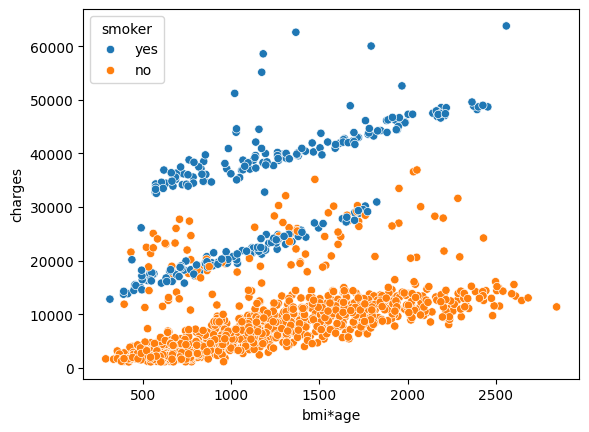

In [249]:
sns.scatterplot(data=df, x=df['bmi'] * df['age'], y='charges', hue='smoker').set_xlabel("bmi*age")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [109]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


In [258]:
#ПРИМИНЕНИЕ МАППИНГА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ. LabelEncoder
df.sex = df.sex.map({
    'female': 0,
    'male': 1
})

df.smoker = df.smoker.map({
    'yes': 1,
    'no': 0
})

df.region = df.region.map({
    'northeast': 0,
    'northwest': 1,
    'southeast': 2,
    'southwest': 3
})

df['bmi_age'] = df['bmi']*df['age']

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_age
0,19,0,27.900,0,1,3,16884.92400,530.100
1,18,1,33.770,1,0,2,1725.55230,607.860
2,28,1,33.000,3,0,2,4449.46200,924.000
3,33,1,22.705,0,0,1,21984.47061,749.265
4,32,1,28.880,0,0,1,3866.85520,924.160


In [256]:
# ДРУГОЙ ПОДХОД. ПРИМЕНЕНИЕ ONE_HOT_ENCODER
from sklearn.preprocessing import OneHotEncoder
# Выбираем категориальные столбцы
categorical_cols = ['sex', 'smoker', 'region']

# Создаём и обучаем энкодер 
encoder = OneHotEncoder(drop='first',sparse_output=False)  # sparse_output=False для получения массива, а не sparse-матрицы
encoded_array = encoder.fit_transform(df[categorical_cols])

# Получаем имена новых столбцов
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Создаём DataFrame с закодированными признаками
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

# Объединяем с исходным DataFrame (без старых категориальных столбцов)
df = pd.concat([df.drop(columns=categorical_cols), df_encoded], axis=1)

df['bmi_age'] = df['bmi']*df['age']
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0,530.100
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0,607.860
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0,924.000
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0,749.265
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0,924.160


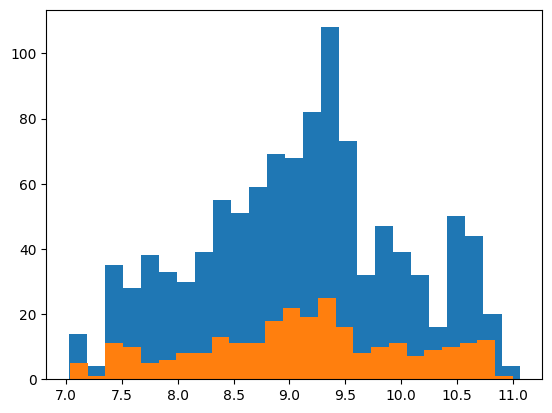

In [112]:
plt.hist(x = y_train,bins=25)
plt.hist(x = y_test,bins=25)
plt.show()

In [223]:
X = df.drop(columns=['charges']).to_numpy()
y = np.log(df.charges) #Расчитывается как log(1 + x)
#y = df.charges/1000

### 📊 Пояснение метрик качества регрессии

- **MSE (Mean Squared Error)** — *среднеквадратичная ошибка*.  
  Чем меньше значение, тем лучше модель. Чувствительна к выбросам, так как ошибки возводятся в квадрат.

- **MAE (Mean Absolute Error)** — *средняя абсолютная ошибка*.  
  Интерпретируется в тех же единицах, что и целевая переменная. Менее чувствительна к выбросам по сравнению с MSE.

- **R² (коэффициент детерминации)** — показывает, **какая доля дисперсии целевой переменной объясняется моделью**.  
  - Значение **от 0 до 1**: чем ближе к 1 — тем лучше.  
  - Может быть **отрицательным**, если модель хуже, чем предсказание среднего значения.

### Linear Regression

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [225]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [226]:
#  Расчёт и вывод метрик.
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.183
Mean Absolute Error (MAE): 0.278
R² Score: 0.7963


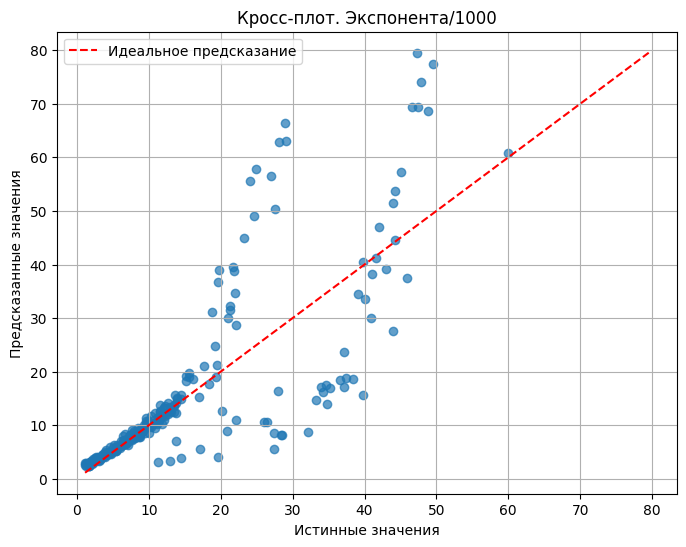

In [220]:
y_test_exp1000, y_pred_exp1000 = np.exp(y_test)/1000,np.exp(y_pred)/1000 # считаем с експонентой и переводим в тыс.долл для удобства
#
plt.figure(figsize=(8, 6))
plt.scatter(y_test_exp1000, y_pred_exp1000, alpha=0.7)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Кросс-плот. Экспонента/1000")

# Диапазон для линии y = x
min_val = min(min(y_test_exp1000), min(y_pred_exp1000))
max_val = max(max(y_test_exp1000), max(y_pred_exp1000))

# Рисуем линию y = x
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')
plt.legend()
plt.grid(True)
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

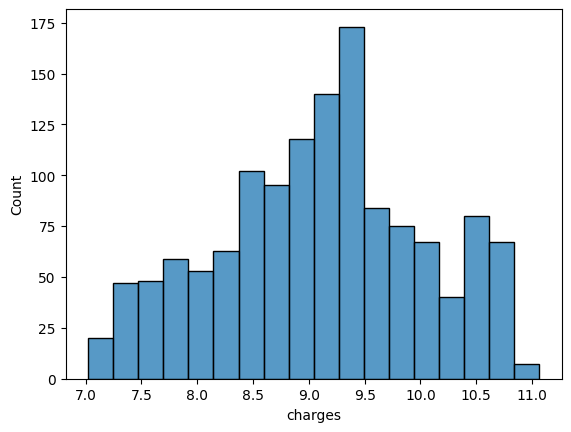

In [251]:
sns.histplot(np.log(df.charges))

In [100]:
np.percentile(df.charges,74)

np.float64(15819.016754)

In [233]:
print(f"R² Score: {r2_score(y_test_exp1000[y_test_exp1000<17], y_pred_exp1000[y_test_exp1000<17]):.4f}")

R² Score: 0.8406


### SVM

In [85]:
from sklearn import svm

model_svm = svm.SVC#(kernel='linear', degree=2)
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
y_pred_svm_test_log = model.predict(X_test)

In [87]:
model.score(X_test, y_test)

0.8042509796155676

In [88]:
y_pred_svm_test = np.expm1(y_pred_svm_test_log)

In [89]:
mse_svm = metrics.mean_squared_error(y_test, y_pred_svm_test_log)
mse_svm

0.17413472651763987

### Decision tree

In [275]:
from sklearn.tree import DecisionTreeRegressor, plot_tree # бывает еще DecisionTreeClassifier
from sklearn.model_selection import  GridSearchCV, cross_val_score

In [280]:
X = df.drop(columns=['charges']).to_numpy()
y = np.log(df.charges) #Расчитывается как log(1 + x)
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

In [ ]:
tree = DecisionTreeRegressor(random_state=777)
tree = DecisionTreeRegressor(criterion='squared_error', # Оптимизируемая метрика. Выбрано MSE(она же и по умолчанию)
                             max_depth=5,               # Максимальная глубина дерева. Контролирует качество обучение. Слишком большая глубина → переобучение
                             min_samples_split = 2,     # узел будет разделён только если в нём ≥ этого числа объектов
                             min_samples_leaf = 3,      # После разделения лист содержит хотя бы столько объектов.Чем больше min_samples_leaf, тем менее переобучена модель.
                             random_state=777)
tree.fit(X_train, y_train) # обучение
y_pred = tree.predict(X_test) # получение предикта

In [274]:
#  Расчёт и вывод метрик.
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.123
R² Score: 0.8627


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_age'],
      dtype='object')

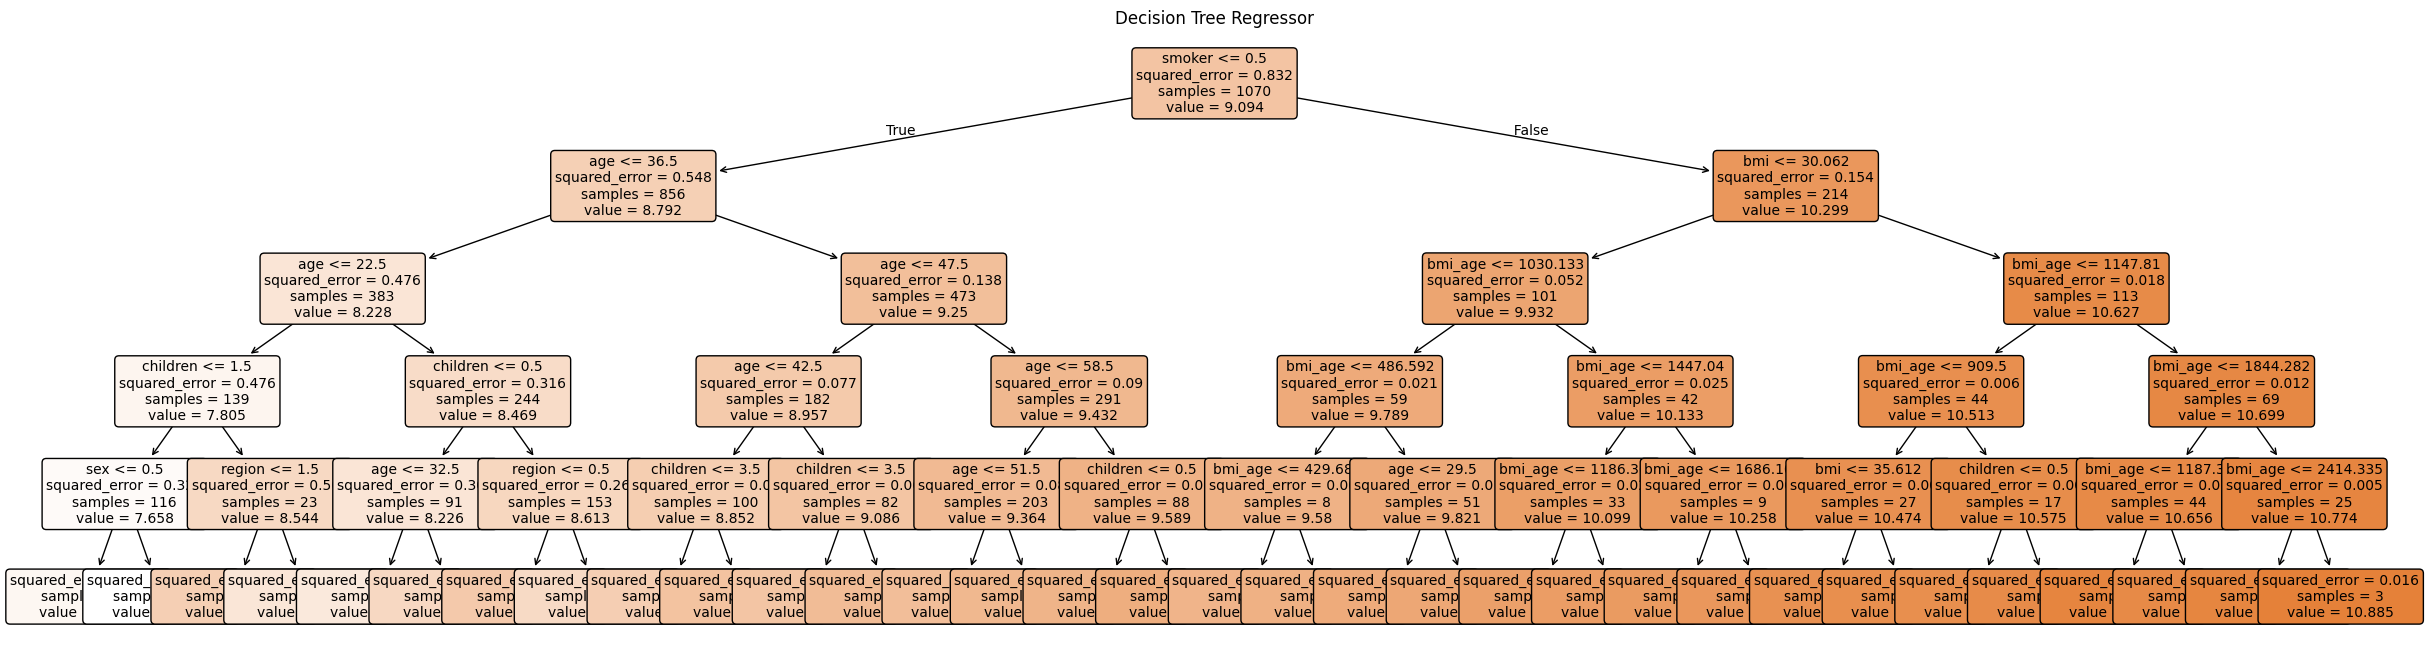

In [279]:
plt.figure(figsize=(30, 8))
plot_tree(tree, 
          feature_names=['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'bmi_age'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Regressor")
plt.show()

In [ ]:
# продвинтый вариант дерева. С перебором
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None] # Ограничитель на кол-во признаков
}
#5*3*3*3 = 135

tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, # число ядер процессора
    verbose=0
)

print("Запуск GridSearchCV")
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
print(f"✅ Лучшие параметры: {grid_search.best_params_}")

#### Random Forest